# Estimating Part-Worth Utilities from Conjoint Choice Data

## Scenario
Using the same meal kit choice survey data, estimate part-worth utilities
and compute attribute importance scores to rank which plan features most
drive customer preference.

## Data: `mealkit_choice_tasks.csv`


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('Exercise_Data')
if not DATA_DIR.exists():
    DATA_DIR = Path('/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Exercises/Udacity Exercises Redone/')

CHOICE_PATH = DATA_DIR / 'mealkit_choice_tasks.csv'
PLANS_PATH  = DATA_DIR / 'mealkit_plans.csv'
ADOPT_PATH  = DATA_DIR / 'mealkit_trial_adoption.csv'
SURVEY_PATH = DATA_DIR / 'mealkit_survey.csv'
MMM_PATH    = DATA_DIR / 'mealkit_marketing_weekly.csv'
from sklearn.linear_model import LogisticRegression
df = pd.read_csv(CHOICE_PATH)
df.head(3)

,respondent_id,task_id,alternative,meals_per_week,cuisine_variety,dietary_options,live_cooking_class,servings,price_per_week,chosen
0,1,1,A,2,premium,yes,no,2,110,0
1,1,1,B,2,premium,no,no,2,110,0
2,1,1,C,6,premium,yes,yes,2,30,1


## Step 1: Encode and Fit Choice Model

In [3]:
df_enc = pd.get_dummies(df,
    columns=['cuisine_variety','dietary_options','live_cooking_class'],
    drop_first=False)
df_enc = df_enc.drop(columns=[
    'cuisine_variety_standard','dietary_options_no','live_cooking_class_no'])
feat_cols = ['price_per_week','meals_per_week','servings',
             'cuisine_variety_premium','dietary_options_yes','live_cooking_class_yes']
X = df_enc[feat_cols].astype(float)
y = df_enc['chosen']
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X, y)
partworths = pd.Series(model.coef_[0], index=feat_cols)
print("Part-worth utilities:")
print(partworths.round(4))

Part-worth utilities:
price_per_week            -0.0352
meals_per_week             0.0706
servings                   0.0646
cuisine_variety_premium    0.3578
dietary_options_yes        0.6781
live_cooking_class_yes     0.3912
dtype: float64


## Step 2: Compute Attribute Importance

In [4]:
# Continuous attributes: importance = |coefficient| × (max − min observed)
# Binary/dummy attributes: importance = |coefficient| (range is always 0 to 1)
importance = {
    'price_per_week':          abs(partworths['price_per_week']) * (df['price_per_week'].max() - df['price_per_week'].min()),
    'meals_per_week':          abs(partworths['meals_per_week']) * (df['meals_per_week'].max() - df['meals_per_week'].min()),
    'servings':                abs(partworths['servings']) * (df['servings'].max() - df['servings'].min()),
    'cuisine_variety_premium': abs(partworths['cuisine_variety_premium']),
    'dietary_options_yes':     abs(partworths['dietary_options_yes']),
    'live_cooking_class_yes':  abs(partworths['live_cooking_class_yes']),
}
imp = pd.Series(importance).sort_values(ascending=False)
print("Attribute importance (range-scaled):")
print(imp.round(4))

Attribute importance (range-scaled):
price_per_week             2.8122
dietary_options_yes        0.6781
live_cooking_class_yes     0.3912
cuisine_variety_premium    0.3578
meals_per_week             0.2823
servings                   0.1938
dtype: float64


## Step 3: Attribute Importance Bar Chart

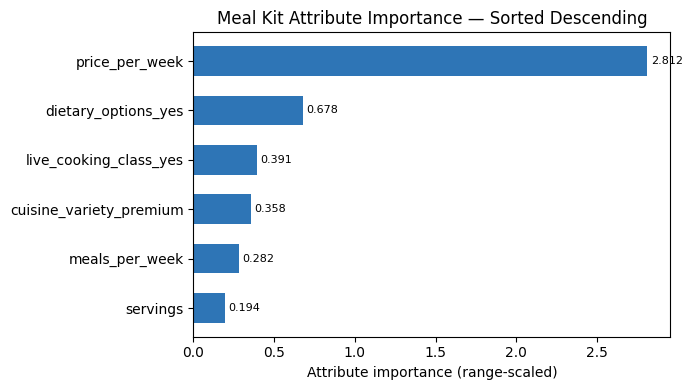

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp.index[::-1], imp.values[::-1], color='#2E75B6', height=0.6)
ax.set_xlabel('Attribute importance (range-scaled)')
ax.set_title('Meal Kit Attribute Importance — Sorted Descending')
for bar, v in zip(ax.patches, imp.values[::-1]):
    ax.text(v + 0.02, bar.get_y() + bar.get_height()/2, f'{v:.3f}',
            va='center', fontsize=8)
plt.tight_layout(); plt.show()

## Reflection

**Highest importance: `price_per_week` (2.812)**
Price dominates because it spans a wide range ($30–$110) and carries a meaningful
coefficient. This is range-amplified importance — a $1 change in price moves utility
by only 0.035, but an $80 span adds up to 2.81 utility units.

**Second: `dietary_options_yes` (0.678)**
Unlike price, dietary options are binary — the full importance is expressed in one
coefficient. Flipping from no dietary options to yes is the single most leveraged
feature improvement available.

**Recommended investment: dietary options.**
Price is partly outside the team's control (margin constraints). Dietary options have
a strong per-unit coefficient AND are an explicit feature add — a direct product
investment decision. If only one feature improvement is possible, dietary accommodation
has the greatest preference uplift.

**Lowest importance: `servings` (0.194)**
Customers show relatively low variation in response to serving count changes
within the tested range. Low leverage for product investment.
